In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#adata = sc.read_h5ad('/Volumes/seq_epiprod02/etorlait/p16/Published_Data/Gray_et_al_2022/Remap_VersionC_Gtf_Terra/Output_Cumulus/LowGeneMin.unknown-rna.h5ad')
#adata=sc.read('/Volumes/seq_epiprod02/etorlait/p16/Published_Data/Gray_et_al_2022/Remap_VersionC_Gtf_Terra
#etorlait/p16/Published_Data/Gray_et_al_2022/Remap_VersionC_Gtf_Terra

In [7]:
#adata

AnnData object with n_obs × n_vars = 554068 × 39212
    obs: 'n_genes', 'n_counts', 'Channel', 'percent_mito', 'scale', 'louvain_labels'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'PCs', 'W_pca', 'df_qcplot', 'genome', 'louvain_resolution', 'modality', 'norm_count', 'pca', 'pca_features', 'pca_knn_distances', 'pca_knn_indices', 'scale.data', 'scale.data.rownames', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_umap'
    varm: 'de_res'

In [8]:
#select_genes=['CDKN2A_p14_ex1','CDKN2A_p16_ex1']
#df=adata[:,adata.var.index.isin(['CDKN2A_p14_ex1','CDKN2A_p16_ex1','CDKN2A_p14_p16'])].to_df()

In [2]:
df = pd.read_csv('Brugge_5_prime.csv', index_col=0)

In [3]:
df_dialup = pd.read_csv("dialup_ratios.csv", index_col=0)

In [4]:
# Extract sample IDs from df (AnnData-derived expression data)
df_sample_ids = df.index.str.split('-').str[0].unique()

# Extract sample IDs from dialup_df (Dial-up ratio data)
dialup_sample_ids = df_dialup.index.str.split('_').str[0].unique()


In [5]:
sample_mapping = {
    "RM_A": "Human-WT-A", "PM_G": "Human-BRCA2-A", "PM_A": "Human-BRCA1-C", "PM_C": "Human-BRCA1-D",
    "PM_K": "Human-BRCA2-B", "PM_I": "Human-BRCA2-C", "PM_J": "Human-BRCA2-D", "RM_D": "Human-WT-C",
    "RM_C": "Human-WT-D", "PM_F": "Human-BRCA1-H", "PM_L": "Human-BRCA2-E"
}

In [6]:
df.head()

,CDKN2A_p16_ex1,CDKN2A_p14_ex1,CDKN2A_p14_p16
barcodekey,,,
PM_A-AAACCTGAGAAACCGC,0.0,0.0,0.0
PM_A-AAACCTGAGAAACGAG,0.0,0.0,0.0
PM_A-AAACCTGAGAACAACT,0.0,0.0,0.0
PM_A-AAACCTGAGAAGGTGA,0.0,0.0,0.0
PM_A-AAACCTGAGACACGAC,0.0,0.0,0.0


In [7]:
df_dialup.head()

,cellSubtype,dialup_p16_ratio_nCounts,dialup_p14_ratio_nCounts
Human-BRCA1-C_AAACCTGAGCAATATG,AP,0.0,0.000000
Human-BRCA1-C_AAACCTGCAAGCCCAC,AP,0.0,0.000084
Human-BRCA1-C_AAACCTGCACGCGAAA,AP,0.0,0.000000
Human-BRCA1-C_AAACCTGCATCCCACT,VE,0.0,0.000000
Human-BRCA1-C_AAACCTGCATCGACGC,M,0.0,0.000000


In [8]:
# Apply the sample mapping to the 'new_barcode' column
def map_barcode(barcode):
    parts = barcode.split('-')
    if parts[0] in sample_mapping:
        return sample_mapping[parts[0]] + '_' + '_'.join(parts[1:])
    else:
        return barcode

In [9]:
map_barcode("PM_A-AAACCTGAGAAACCGC")

'Human-BRCA1-C_AAACCTGAGAAACCGC'

In [10]:
# Create a new column 'new_barcode' in df
df['new_barcode'] = df.index

df['new_barcode'] = df['new_barcode'].apply(map_barcode)
df

,CDKN2A_p16_ex1,CDKN2A_p14_ex1,CDKN2A_p14_p16,new_barcode
barcodekey,,,,
PM_A-AAACCTGAGAAACCGC,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGAGAAACCGC
PM_A-AAACCTGAGAAACGAG,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGAGAAACGAG
PM_A-AAACCTGAGAACAACT,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGAGAACAACT
PM_A-AAACCTGAGAAGGTGA,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGAGAAGGTGA
PM_A-AAACCTGAGACACGAC,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGAGACACGAC
...,...,...,...,...
RM_D-TTTGTCATCTAACGGT,0.0,0.0,0.0,Human-WT-C_TTTGTCATCTAACGGT
RM_D-TTTGTCATCTCAACTT,0.0,0.0,0.0,Human-WT-C_TTTGTCATCTCAACTT
RM_D-TTTGTCATCTGATACG,0.0,0.0,0.0,Human-WT-C_TTTGTCATCTGATACG


In [11]:
# Merge df and df_dialup based on 'new_barcode' and index, respectively.
merged_df = pd.merge(df, df_dialup, left_on='new_barcode', right_index=True, how='inner')

# Discard rows in merged_df where 'new_barcode' is not found in df_dialup's index
# This is already handled by the 'inner' join in pd.merge.

# Display the merged DataFrame
merged_df

,CDKN2A_p16_ex1,CDKN2A_p14_ex1,CDKN2A_p14_p16,new_barcode,cellSubtype,dialup_p16_ratio_nCounts,dialup_p14_ratio_nCounts
barcodekey,,,,,,,
PM_A-AAACCTGAGCAATATG,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGAGCAATATG,AP,0.0,0.000000
PM_A-AAACCTGCAAGCCCAC,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCAAGCCCAC,AP,0.0,0.000084
PM_A-AAACCTGCACGCGAAA,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCACGCGAAA,AP,0.0,0.000000
PM_A-AAACCTGCATCCCACT,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCATCCCACT,VE,0.0,0.000000
PM_A-AAACCTGCATCGACGC,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCATCGACGC,M,0.0,0.000000
...,...,...,...,...,...,...,...
RM_D-TTTGGTTTCACTTCAT,0.0,0.0,0.0,Human-WT-C_TTTGGTTTCACTTCAT,HSb,0.0,0.000171
RM_D-TTTGGTTTCAGTGCAT,0.0,0.0,0.0,Human-WT-C_TTTGGTTTCAGTGCAT,BAP1,0.0,0.000000
RM_D-TTTGGTTTCCGCAAGC,0.0,0.0,0.0,Human-WT-C_TTTGGTTTCCGCAAGC,PE,0.0,0.000000


In [12]:
# Rename columns in merged_df
merged_df = merged_df.rename(columns={
    'CDKN2A_p16_ex1': 'CDKN2A-p16',
    'CDKN2A_p14_ex1': 'CDKN2A-p14',
    'CDKN2A_p14_p16': 'CDKN2A-p14+p16',
    'dialup_p16_ratio_nCounts': 'dialup-p16',
    'dialup_p14_ratio_nCounts': 'dialup-p14'
})

# The rest of your code remains the same, but now uses the new column names.
# For example, the genes list should be updated:
genes = ['CDKN2A-p16', 'CDKN2A-p14', 'CDKN2A-p14+p16', 'dialup-p16', 'dialup-p14']
merged_df

,CDKN2A-p16,CDKN2A-p14,CDKN2A-p14+p16,new_barcode,cellSubtype,dialup-p16,dialup-p14
barcodekey,,,,,,,
PM_A-AAACCTGAGCAATATG,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGAGCAATATG,AP,0.0,0.000000
PM_A-AAACCTGCAAGCCCAC,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCAAGCCCAC,AP,0.0,0.000084
PM_A-AAACCTGCACGCGAAA,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCACGCGAAA,AP,0.0,0.000000
PM_A-AAACCTGCATCCCACT,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCATCCCACT,VE,0.0,0.000000
PM_A-AAACCTGCATCGACGC,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCATCGACGC,M,0.0,0.000000
...,...,...,...,...,...,...,...
RM_D-TTTGGTTTCACTTCAT,0.0,0.0,0.0,Human-WT-C_TTTGGTTTCACTTCAT,HSb,0.0,0.000171
RM_D-TTTGGTTTCAGTGCAT,0.0,0.0,0.0,Human-WT-C_TTTGGTTTCAGTGCAT,BAP1,0.0,0.000000
RM_D-TTTGGTTTCCGCAAGC,0.0,0.0,0.0,Human-WT-C_TTTGGTTTCCGCAAGC,PE,0.0,0.000000


In [13]:
# Create a new column 'sample' from the 'barcodekey' column
merged_df['sample'] = merged_df['new_barcode'].str.split('_').str[0]
merged_df

,CDKN2A-p16,CDKN2A-p14,CDKN2A-p14+p16,new_barcode,cellSubtype,dialup-p16,dialup-p14,sample
barcodekey,,,,,,,,
PM_A-AAACCTGAGCAATATG,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGAGCAATATG,AP,0.0,0.000000,Human-BRCA1-C
PM_A-AAACCTGCAAGCCCAC,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCAAGCCCAC,AP,0.0,0.000084,Human-BRCA1-C
PM_A-AAACCTGCACGCGAAA,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCACGCGAAA,AP,0.0,0.000000,Human-BRCA1-C
PM_A-AAACCTGCATCCCACT,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCATCCCACT,VE,0.0,0.000000,Human-BRCA1-C
PM_A-AAACCTGCATCGACGC,0.0,0.0,0.0,Human-BRCA1-C_AAACCTGCATCGACGC,M,0.0,0.000000,Human-BRCA1-C
...,...,...,...,...,...,...,...,...
RM_D-TTTGGTTTCACTTCAT,0.0,0.0,0.0,Human-WT-C_TTTGGTTTCACTTCAT,HSb,0.0,0.000171,Human-WT-C
RM_D-TTTGGTTTCAGTGCAT,0.0,0.0,0.0,Human-WT-C_TTTGGTTTCAGTGCAT,BAP1,0.0,0.000000,Human-WT-C
RM_D-TTTGGTTTCCGCAAGC,0.0,0.0,0.0,Human-WT-C_TTTGGTTTCCGCAAGC,PE,0.0,0.000000,Human-WT-C


In [20]:
# Calculate the overall percentage of cells expressing each gene (i.e., where expression > 0)
total_cells = len(merged_df)
percentages = [np.sum(merged_df[gene] > 0) / total_cells * 100 for gene in genes]

# Calculate the standard error of the mean (SEM) per sample for each gene
sems = [merged_df.groupby('sample')[gene].apply(lambda x: (x > 0).mean()).sem() * 100 for gene in genes]

# Prepare the data for plotting
labels = genes
means = percentages
errors = sems

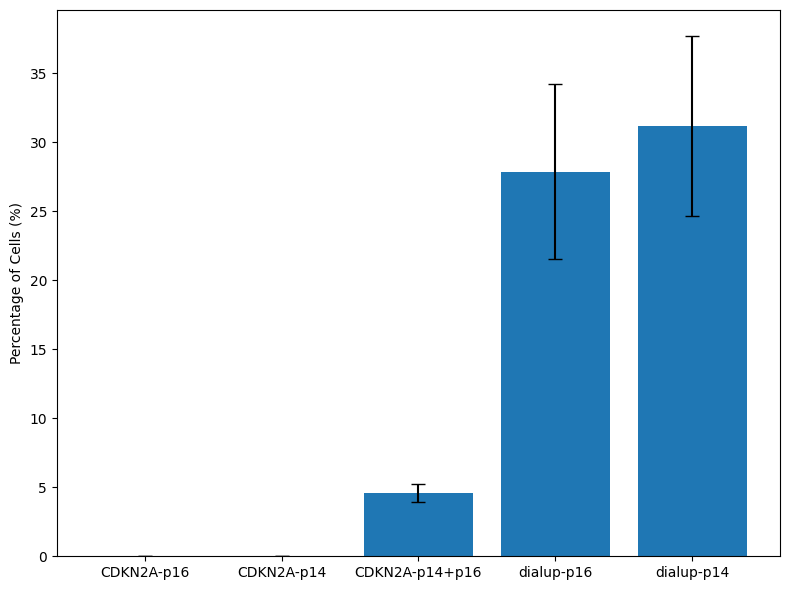

In [21]:
# Plot the overall bar chart with error bars
plt.figure(figsize=(8, 6))
bar_width = 0.5

plt.bar(labels, means, yerr=errors, capsize=5)

# Customize the plot
plt.ylabel('Percentage of Cells (%)')

# Show the plot
plt.tight_layout()
plt.show()